# Statistics sheet 7

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import binom, norm, poisson, chi2
from scipy.special import comb

plt.style.use('science')
plt.rcParams.update({'font.size': 14})

## Exercise 1: Simpson Paradoxon

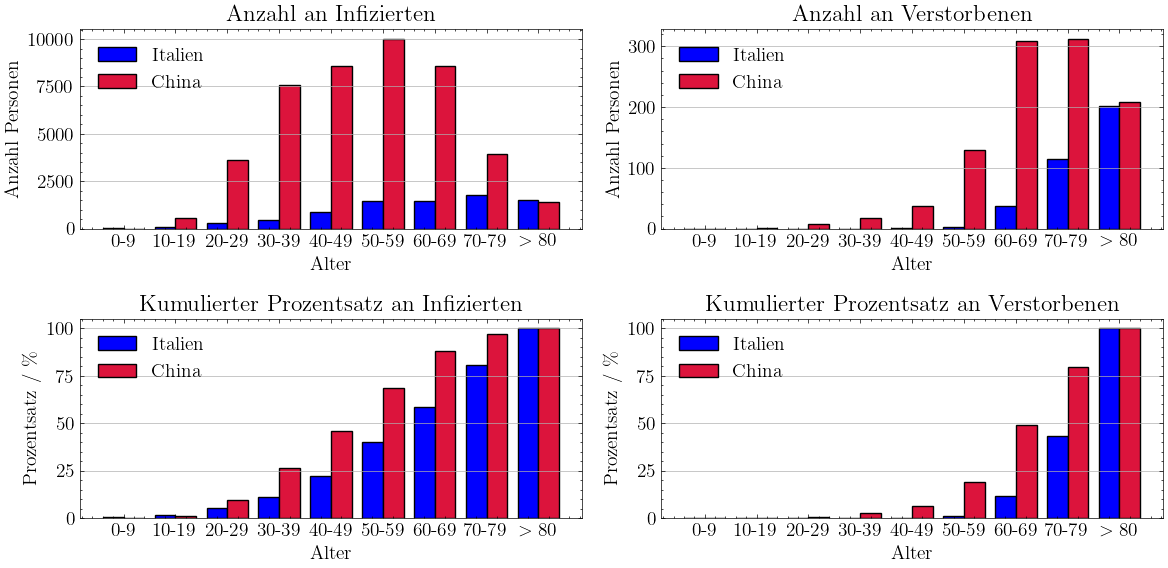

In [104]:
data = {
    "Altersgruppe": ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", r"$>80$"],
    "Infiziert_Italien": [43, 85, 296, 470, 891, 1453, 1471, 1785, 1532],
    "Verstorben_Italien": [0, 0, 0, 0, 1, 3, 37, 114, 202],
    "Infiziert_China": [0, 549, 3619, 7600, 8571, 10008, 8583, 3918, 1408],
    "Verstorben_China": [0, 1, 7, 18, 38, 130, 309, 312, 208]
}

x = np.arange(len(data["Altersgruppe"]))
width = 0.4

inf_it = np.array(data["Infiziert_Italien"])
inf_ch = np.array(data["Infiziert_China"])
dead_it = np.array(data["Verstorben_Italien"])
dead_ch = np.array(data["Verstorben_China"])

cum_inf_it = np.cumsum(inf_it) / np.sum(inf_it) * 100
cum_inf_ch = np.cumsum(inf_ch) / np.sum(inf_ch) * 100
cum_dead_it = np.cumsum(dead_it) / np.sum(dead_it) * 100
cum_dead_ch = np.cumsum(dead_ch) / np.sum(dead_ch) * 100

fig, axs = plt.subplots(2, 2, figsize=(12, 6))

axs[0, 0].bar(x - width/2, inf_it, width, label="Italien", color="blue", edgecolor='black')
axs[0, 0].bar(x + width/2, inf_ch, width, label="China", color="crimson", edgecolor='black')
axs[0, 0].set_title("Anzahl an Infizierten")
axs[0, 0].set_ylabel("Anzahl Personen")

axs[0, 1].bar(x - width/2, dead_it, width, label="Italien", color="blue", edgecolor='black')
axs[0, 1].bar(x + width/2, dead_ch, width, label="China", color="crimson", edgecolor='black')
axs[0, 1].set_title("Anzahl an Verstorbenen")
axs[0, 1].set_ylabel("Anzahl Personen")

axs[1, 0].bar(x - width/2, cum_inf_it, width, label="Italien", color="blue", edgecolor='black')
axs[1, 0].bar(x + width/2, cum_inf_ch, width, label="China", color="crimson", edgecolor='black')
axs[1, 0].set_title("Kumulierter Prozentsatz an Infizierten")
axs[1, 0].set_ylabel(r"Prozentsatz / $\%$")

axs[1, 1].bar(x - width/2, cum_dead_it, width, label="Italien", color="blue", edgecolor='black')
axs[1, 1].bar(x + width/2, cum_dead_ch, width, label="China", color="crimson", edgecolor='black')
axs[1, 1].set_title("Kumulierter Prozentsatz an Verstorbenen")
axs[1, 1].set_ylabel(r"Prozentsatz / $\%$")

for ax in axs.flat:
    ax.set_xlabel("Alter")
    ax.set_xticks(x)
    ax.set_xticklabels(data["Altersgruppe"])
    ax.legend()
    ax.grid(axis='y', linestyle='-') 

plt.tight_layout()
plt.show()

## Exercise 02: Test auf Normalverteilung

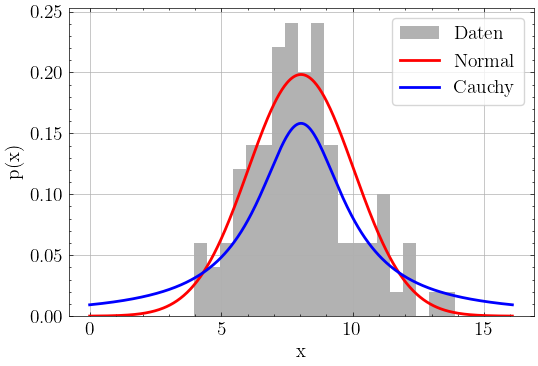

Odds-Ratio: 52888523081.3862


In [17]:
data = np.loadtxt('data/data.txt')

mu = np.mean(data)
sig = np.std(data, ddof=1)

pdf_normal = lambda x,mu,sig : 1 / (np.sqrt(2*np.pi) * sig) * np.exp(-(x - mu)**2 / (2*sig**2))
pdf_cauchy = lambda x,mu,sig : 1 / np.pi * sig / ((x - mu)**2 + sig**2)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=20, density=True, alpha=0.6, color='gray', label='Daten')

x = np.linspace(mu - 4*sig, mu + 4*sig, 500)
plt.plot(x, pdf_normal(x, mu, sig), 'r-', lw=2, label='Normal')
plt.plot(x, pdf_cauchy(x, mu, sig), 'b-', lw=2, label='Cauchy')

plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid()
plt.legend(frameon=True)
plt.show()

O_NC = np.prod(pdf_normal(data,mu,sig) / pdf_cauchy(data,mu,sig))


print(f"Odds-Ratio: {O_NC:.4f}")

## Exercise 3: Urnen

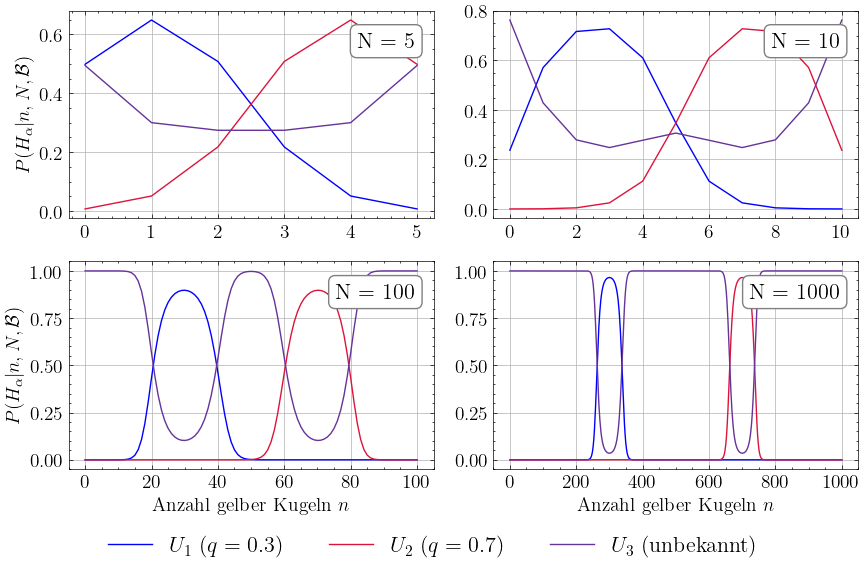

In [55]:
binomial_dist = lambda n, N, q: comb(N, n) * q**n * (1-q)**(N-n)
N_list = [5, 10, 100, 1000]
q1 = 0.3
q2 = 0.7

# Die Höhe (figsize) wurde leicht erhöht, um Platz für die Legende unten zu machen
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

for i, N in enumerate(N_list):
    row, col = np.unravel_index(i, (2, 2))
    ax = axes[row, col]
    n = np.arange(0, N + 1)
    
    p_U1 = binomial_dist(n, N, q1)
    p_U2 = binomial_dist(n, N, q2)
    p_U3 = np.ones_like(n) / (N + 1)
    
    # Nenner des Bayes-Theorems (Schnittmengen-Summe)
    marginal_prob = p_U1 + p_U2 + p_U3
    
    # A-posteriori-Wahrscheinlichkeiten
    P_H1 = p_U1 / marginal_prob
    P_H2 = p_U2 / marginal_prob
    P_H3 = p_U3 / marginal_prob
    
    # Plotten und Linien-Objekte für die gemeinsame Legende speichern
    line1, = ax.plot(n, P_H1, color='blue', label='$U_1$ ($q=0.3$)')
    line2, = ax.plot(n, P_H2, color='crimson', label='$U_2$ ($q=0.7$)')
    line3, = ax.plot(n, P_H3, color='rebeccapurple', label='$U_3$ (unbekannt)')
    
    ax.text(0.95, 0.9, f'N = {N}', transform=ax.transAxes, fontsize=16,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=1.0, edgecolor='gray', boxstyle='round,pad=0.3'))
    ax.grid()
    if row == 1:
        ax.set_xlabel(r'Anzahl gelber Kugeln $n$', fontsize=14)
    if col == 0:
        ax.set_ylabel(r'$P(H_\alpha | n, N, \mathcal{B})$', fontsize=14)

# Eine einzige, gemeinsame Legende ganz unten platzieren
fig.legend(handles=[line1, line2, line3], loc='lower center', ncol=3, fontsize=16)

# rect=[0, 0.06, 1, 1] sorgt dafür, dass die subplots Platz für die Legende lassen
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

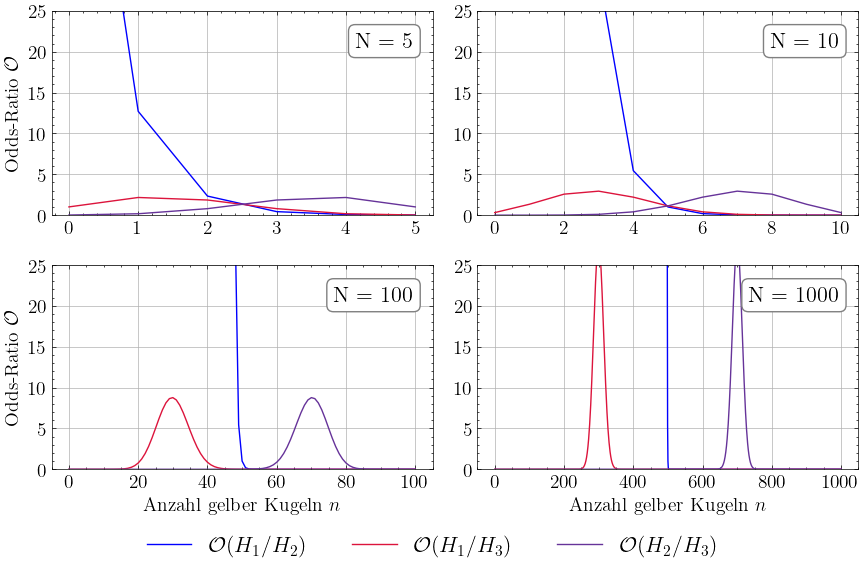

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

binomial_dist = lambda n, N, q: comb(N, n) * q**n * (1-q)**(N-n)
N_list = [5, 10, 100, 1000]
q1 = 0.3
q2 = 0.7

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

for i, N in enumerate(N_list):
    row, col = np.unravel_index(i, (2, 2))
    ax = axes[row, col]
    n = np.arange(0, N + 1)
    
    p_U1 = binomial_dist(n, N, q1)
    p_U2 = binomial_dist(n, N, q2)
    p_U3 = np.ones_like(n) / (N + 1)
    
    marginal_prob = p_U1 + p_U2 + p_U3
    
    P_H1 = p_U1 / marginal_prob
    P_H2 = p_U2 / marginal_prob
    P_H3 = p_U3 / marginal_prob
    
    with np.errstate(divide='ignore', invalid='ignore'):
        O_1_2 = P_H1 / P_H2
        O_1_3 = P_H1 / P_H3
        O_2_3 = P_H2 / P_H3
    
    line1, = ax.plot(n, O_1_2, color='blue', label=r'$\mathcal{O}(H_1 / H_2)$')
    line2, = ax.plot(n, O_1_3, color='crimson', label=r'$\mathcal{O}(H_1 / H_3)$')
    line3, = ax.plot(n, O_2_3, color='rebeccapurple', label=r'$\mathcal{O}(H_2 / H_3)$')
    ax.grid()

    ax.text(0.95, 0.9, f'N = {N}', transform=ax.transAxes, fontsize=16,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=1.0, edgecolor='gray', boxstyle='round,pad=0.3'))
    
    ax.set_ylim(0, 25)
    
    if row == 1:
        ax.set_xlabel(r'Anzahl gelber Kugeln $n$', fontsize=14)
    if col == 0:
        ax.set_ylabel(r'Odds-Ratio $\mathcal{O}$', fontsize=14)

fig.legend(handles=[line1, line2, line3], loc='lower center', ncol=3, fontsize=16)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## Exercise 4: $\chi^2$-Test Lotto

In [ ]:
lotto_data = np.loadtxt('data/Lotto.csv', delimiter=';', dtype=np.int32)
num, x_n = lotto_data.T

N = np.sum(x_n)
nu = 45 - 1
alpha = 0.01
x_0n = N / 45

chi2_stat = np.sum((x_n - x_0n)**2 / x_0n)

x_0 = chi2.ppf(1 - alpha, df=nu)
print("--- ERGEBNIS CHI-QUADRAT-TEST ---")
print(f"Gesamtanzahl gezogener Zahlen (N): {N}")
print(f"Freiheitsgrade (nu): {nu}")
print(f"Berechnete Prüfgröße (chi2): {chi2_stat:.4f}")
print(f"Kritischer Wert (x0): {x_0:.4f}")
print("---------------------------------")



print(f"Ergebnis: chi2 ({chi2_stat:.4f}) <= x0 ({x_0:.4f})")
print("-> Die Nullhypothese H_0 wird BEIBEHALTEN.")
print("Es gibt keinen statistisch signifikanten Beleg gegen die Gleichverteilung.")

--- ERGEBNIS CHI-QUADRAT-TEST ---
Gesamtanzahl gezogener Zahlen (N): 6630
Freiheitsgrade (nu): 44
Berechnete Prüfgröße (chi2): 36.6652
Kritischer Wert (x0): 68.7095
---------------------------------
Ergebnis: chi2 (36.6652) <= x0 (68.7095)
-> Die Nullhypothese H0 wird BEIBEHALTEN.
Es gibt keinen statistisch signifikanten Beleg gegen die Gleichverteilung.


## Exercise 5: $\chi^2$ Zählrate

Poisson: chi2 = 4.71, kritischer Wert = 11.07 -> H0 AKZEPTIERT
Normal:  chi2 = 4.58, kritischer Wert = 9.49 -> H0 AKZEPTIERT


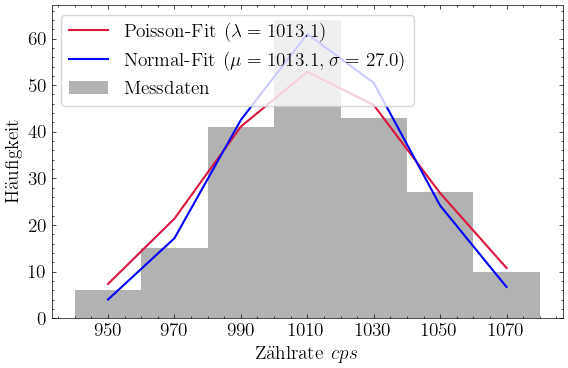

In [89]:
cr_data = np.loadtxt('data/Zaehlrate.csv', dtype=np.int32)

mu_ml = np.mean(cr_data)
sigma_ml = np.std(cr_data)
lambda_ml = mu_ml

bins = np.arange(940, 1080 + 20, 20)
bin_centers = bins[:-1] + 10
L = len(bins) - 1

n_l, _ = np.histogram(cr_data, bins=bins)
N = np.sum(n_l) 

p_poisson = poisson.pmf(bin_centers, lambda_ml)
x0_l_poisson = N * (p_poisson / np.sum(p_poisson))

p_norm = norm.pdf(bin_centers, mu_ml, sigma_ml)
x0_l_norm = N * (p_norm / np.sum(p_norm)) 

# Chi-Quadrat-Test
alpha = 0.05

chi2_poisson = np.sum((n_l - x0_l_poisson)**2 / x0_l_poisson)
nu_poisson = L - 1 - 1 
x0_poisson = chi2.ppf(1 - alpha, df=nu_poisson)

chi2_norm = np.sum((n_l - x0_l_norm)**2 / x0_l_norm)
nu_norm = L - 1 - 2 
x0_norm = chi2.ppf(1 - alpha, df=nu_norm) 

print(f"Poisson: chi2 = {chi2_poisson:.2f}, kritischer Wert = {x0_poisson:.2f} -> H0 " 
      f"{'ABGELEHNT' if chi2_poisson > x0_poisson else 'AKZEPTIERT'}")
print(f"Normal:  chi2 = {chi2_norm:.2f}, kritischer Wert = {x0_norm:.2f} -> H0 " 
      f"{'ABGELEHNT' if chi2_norm > x0_norm else 'AKZEPTIERT'}")

plt.figure(figsize=(6, 4))

plt.bar(bins[:-1], n_l, width=20, align='edge', alpha=0.6, color='gray', label='Messdaten')

plt.plot(bins[:-1] + 10, x0_l_poisson, color='crimson', lw=1.5, label=fr'Poisson-Fit ($\lambda={lambda_ml:.1f}$)')
plt.plot(bins[:-1] + 10, x0_l_norm, color='blue', lw=1.5, label=fr'Normal-Fit ($\mu={mu_ml:.1f}, \sigma={sigma_ml:.1f}$)')

plt.xlabel('Zählrate $cps$')
plt.ylabel('Häufigkeit') 
plt.xticks(bin_centers) 
plt.legend(frameon=True, loc='upper left') 
plt.tight_layout()
plt.show()